# Spatial Models Demo: SAR-MNL with `graph=` and `lag=True`

This notebook demonstrates the four spatial logit model variants in `locpick`. When `lag=True` is combined with `graph=`, the model becomes a Spatial Autoregressive (SAR) logit — alternatives influence each other through a spatial weights matrix:

- **`ChoiceModel(..., graph=g, lag=True)`** — SAR-MNL (spatial autoregressive logit)
- **`ChoiceModel(..., graph=g, nests=..., lag=True)`** — SAR + nesting
- **`ChoiceModel(..., graph=g, random_params=..., lag=True)`** — SAR + random taste variation
- **`ChoiceModel(..., graph=g, nests=..., random_params=..., lag=True)`** — SAR + nesting + random variation

We use synthetic data generated by `simulate_sar_mnl` with a known spatial adjacency structure from DC census tracts.

In [1]:
import numpy as np
import pandas as pd

from locpick import ChoiceModel
from locpick.dgp import simulate_sar_mnl
from locpick.models.mixed import ParamDistribution
from locpick.models.nested import NestingTree, NestSpec

In [2]:
import geosnap as gsp

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [3]:
datasets = gsp.DataStore()

In [4]:
dc = gsp.io.get_acs(datasets, years=2019, level="tract", state_fips="11")

<Axes: >

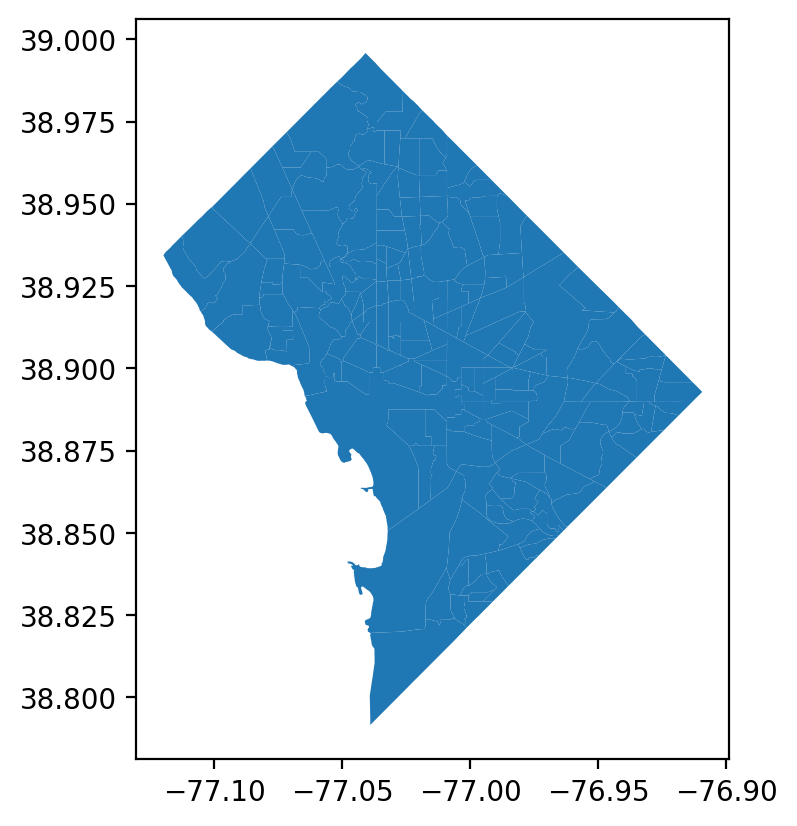

In [5]:
dc.plot()

In [6]:
from libpysal.graph import Graph

dc_graph = Graph.build_contiguity(dc, rook=False).transform("r")

## 2. Generate Synthetic Data

We use `simulate_sar_mnl` to create a synthetic dataset with known spatial autoregressive structure. The DGP produces:
- `choosers`: household-level observations with a random feature
- `alternatives`: tract-level attributes (`cost`, `time`)
- `W`: a spatial weights matrix as a `libpysal.graph.Graph`
- `true_rho`: the ground-truth spatial autoregressive parameter

In [7]:
# Generate synthetic SAR-MNL data with spatial correlation
n_obs = 2000
n_alts = dc.shape[0]

scl_dataset = simulate_sar_mnl(
    n_obs=n_obs,
    n_alts=n_alts,
    alt_params={"cost": -0.5, "time": -0.2},
    rho=0.5,
    seed=42,
    W=dc_graph,
)

ct = scl_dataset.choice_table
print(f"Observations: {ct.n_observations}")
print(f"Alternatives: {ct.n_alternatives}")
print(f"True rho: {scl_dataset.true_rho}")
print(f"W shape: {scl_dataset.W.sparse.shape}")

Observations: 2000
Alternatives: 179
True rho: 0.5
W shape: (179, 179)


## 3. Configure Spatial Models

We configure four SAR model variants:

1. **`ChoiceModel(graph=g, lag=True)`** — spatial autoregressive logit only
2. **`ChoiceModel(graph=g, nests=..., lag=True)`** — spatial + nesting structure
3. **`ChoiceModel(graph=g, random_params=..., lag=True)`** — spatial + random taste variation
4. **`ChoiceModel(graph=g, nests=..., random_params=..., lag=True)`** — spatial + nesting + random variation

Each model shares the same `ChoiceTable` and formula but adds structural complexity. The `graph` parameter accepts a `libpysal.graph.Graph`, a `scipy.sparse` array, or a dense numpy adjacency matrix.

In [8]:
# Common formula for all models — must match columns generated by simulate_sar_mnl
formula = "cost + time - 1"

# Use the Graph from the DGP directly (preferred input type)
W = scl_dataset.W

# 1. SAR MNL
model_scl = ChoiceModel(ct, formula=formula, graph=W, lag=True)

# 2. SAR NestedMNL — spatial + nesting
nest_tree = NestingTree(
    nests=[
        NestSpec(name="urban", alt_ids=list(range(0, n_alts // 2))),
        NestSpec(name="suburban", alt_ids=list(range(n_alts // 2, n_alts))),
    ]
)

model_nested_scl = ChoiceModel(ct, formula=formula, graph=W, nests=nest_tree, lag=True)

# 3. SAR MixedMNL — spatial + random coefficients
random_params = {
    "time": ParamDistribution(distribution="normal", param="time"),
}

model_mixed_scl = ChoiceModel(
    ct, formula=formula, graph=W, random_params=random_params, n_draws=100, lag=True
)

# 4. SAR MixedNestedMNL — spatial + nesting + random coefficients
model_mixed_nested_scl = ChoiceModel(
    ct,
    formula=formula,
    graph=W,
    nests=nest_tree,
    random_params=random_params,
    n_draws=100,
    lag=True,
)

print("Models configured:")
print(f"  Spatial MNL:            {type(model_scl).__name__}")
print(f"  Spatial NestedMNL:      {type(model_nested_scl).__name__}")
print(f"  Spatial MixedMNL:       {type(model_mixed_scl).__name__}")
print(f"  Spatial MixedNestedMNL: {type(model_mixed_nested_scl).__name__}")

Models configured:
  Spatial MNL:            ChoiceModel
  Spatial NestedMNL:      ChoiceModel
  Spatial MixedMNL:       ChoiceModel
  Spatial MixedNestedMNL: ChoiceModel


## 4. Fit Spatial Models

Fit each model and inspect the estimated coefficients. SAR-MNL estimates a `rho` parameter that captures spatial autocorrelation. The nested variant adds `lambda` nest dissimilarity parameters. The mixed variant adds `sd_*` random-coefficient standard deviations.

In [9]:
# Fit spatial MNL
result_scl = model_scl.fit()
print("=== Spatial MNL ===")
print(result_scl.summary())

=== Spatial MNL ===
Spatial Autoregressive Logit Estimation Results
Observations:            2000
Alternatives:             179
Parameters:                3
DF residual:             1997
------------------------------------------------------------
Log-likelihood:  -10153.9946
LL (null):        -10374.7716
AIC:               20313.9892
BIC:               20330.7919
Rho-squared:           0.0213
Adj. rho-sq:           0.0210
------------------------------------------------------------
Parameter                  Coef    Std.Err        t    P>|t|
------------------------------------------------------------
cost                    -0.4955     0.0250  -19.846   0.0000
time                    -0.2009     0.0216   -9.294   0.0000
rho                      0.4761     0.0704    6.761   0.0000


In [10]:
# Fit spatial NestedMNL
result_nested_scl = model_nested_scl.fit()
print("=== Spatial NestedMNL ===")
print(result_nested_scl.summary())

=== Spatial NestedMNL ===
Nested Spatial Autoregressive Logit Estimation Results
Observations:            2000
Alternatives:             179
Parameters:                5
DF residual:             1995
------------------------------------------------------------
Log-likelihood:  -10151.9409
LL (null):        -10374.7716
AIC:               20313.8819
BIC:               20341.8864
Rho-squared:           0.0215
Adj. rho-sq:           0.0210
------------------------------------------------------------
Parameter                  Coef    Std.Err        t    P>|t|
------------------------------------------------------------
cost                    -0.2472     0.4650   -0.532   0.5950
time                    -0.0990     0.1895   -0.522   0.6013
rho                      0.4795     0.0707    6.783   0.0000
lambda_urban             0.5201     0.9419    0.552   0.5808
lambda_suburban          0.4851     0.9698    0.500   0.6169


In [11]:
# Fit spatial MixedMNL
result_mixed_scl = model_mixed_scl.fit()
print("=== Spatial MixedMNL ===")
print(result_mixed_scl.summary())

/Users/knaaptime/Dropbox/projects/locpick/locpick/models/mixed.py:204: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  uniform = sampler.random(n=n_total)


=== Spatial MixedMNL ===
Mixed Spatial Autoregressive Logit Estimation Results
Observations:            2000
Alternatives:             179
Parameters:                4
DF residual:             1996
------------------------------------------------------------
Log-likelihood:  -10156.6864
LL (null):        -10374.7716
AIC:               20321.3727
BIC:               20343.7763
Rho-squared:           0.0210
Adj. rho-sq:           0.0206
------------------------------------------------------------
Parameter                  Coef    Std.Err        t    P>|t|
------------------------------------------------------------
cost                    -0.4950     0.0251  -19.697   0.0000
rho                      0.4754     0.0829    5.736   0.0000
mean_time               -0.1931     0.0217   -8.911   0.0000
sd_time                  2.6655     2.6871    0.992   0.3212


In [12]:
# Fit spatial MixedNestedMNL
result_mixed_nested_scl = model_mixed_nested_scl.fit()
print("=== Spatial MixedNestedMNL ===")
print(result_mixed_nested_scl.summary())

/Users/knaaptime/Dropbox/projects/locpick/locpick/models/mixed.py:204: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  uniform = sampler.random(n=n_total)
E0707 10:34:57.414647 1186740 slow_operation_alarm.cc:73] Constant folding an instruction is taking > 1s:

  %reduce-window.4 = f64[100,2000,6]{2,1,0} reduce-window(%broadcast_in_dim.115, %constant.130), window={size=1x1x32 stride=1x1x32 pad=0_0x0_0x6_7}, to_apply=%region_12.23

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
E0707 10:35:11.927976 1186738 slow_operation_alarm.cc:140] The operation took 15.518408s
Constant folding an instruction is taki

=== Spatial MixedNestedMNL ===
Mixed Nested Spatial Autoregressive Logit Estimation Results
Observations:            2000
Alternatives:             179
Parameters:                6
DF residual:             1994
------------------------------------------------------------
Log-likelihood:  -10154.4431
LL (null):        -10374.7716
AIC:               20320.8862
BIC:               20354.4916
Rho-squared:           0.0212
Adj. rho-sq:           0.0207
------------------------------------------------------------
Parameter                  Coef    Std.Err        t    P>|t|
------------------------------------------------------------
cost                    -0.1473     0.0935   -1.574   0.1154
rho                      0.4763     0.0820    5.812   0.0000
lambda_urban             0.3174     0.1885    1.684   0.0922
lambda_suburban          0.2770     0.1915    1.447   0.1480
mean_time               -0.0558     0.0367   -1.522   0.1281
sd_time                  3.6038     1.7594    2.048   0.0405


## 7. Visualize Spatial Autocorrelation

The SAR spatial filter $(I - \rho W)^{-1}$ creates spatial autocorrelation across alternatives. Since alternatives are spatial locations connected by $W$, nearby locations have more similar utilities than distant ones. We verify this by computing Moran's I on the utility vectors and mapping the spatial pattern.

In [13]:
# Collect fit statistics for comparison
results = {
    "Spatial MNL": result_scl,
    "Spatial NestedMNL": result_nested_scl,
    "Spatial MixedMNL": result_mixed_scl,
    "Spatial MixedNestedMNL": result_mixed_nested_scl,
}

comparison = pd.DataFrame(
    {
        name: {
            "Log-Likelihood": r.log_likelihood,
            "Null LL": r.log_likelihood_null,
            "AIC": r.aic,
            "BIC": r.bic,
            "Rho²": r.rho_squared,
            "Adj. Rho²": r.rho_bar_squared,
            "n_params": r.n_parameters,
        }
        for name, r in results.items()
    }
).T

print(comparison.round(4))

                        Log-Likelihood     Null LL         AIC         BIC  \
Spatial MNL                -10153.9946 -10374.7716  20313.9892  20330.7919   
Spatial NestedMNL          -10151.9409 -10374.7716  20313.8819  20341.8864   
Spatial MixedMNL           -10156.6864 -10374.7716  20321.3727  20343.7763   
Spatial MixedNestedMNL     -10154.4431 -10374.7716  20320.8862  20354.4916   

                          Rho²  Adj. Rho²  n_params  
Spatial MNL             0.0213     0.0210       3.0  
Spatial NestedMNL       0.0215     0.0210       5.0  
Spatial MixedMNL        0.0210     0.0206       4.0  
Spatial MixedNestedMNL  0.0212     0.0207       6.0  


## 6. Predict Choice Probabilities

Predict choice probabilities for the SAR model. Since we only have alternative-level attributes (`cost`, `time`), all choosers have the same probability vector — the spatial structure comes entirely from the spatial filter $(I - \rho W)^{-1}$.

In [14]:
# Predict probabilities using model.probabilities() (no arguments uses fitted parameters)
probs_scl = model_scl.probabilities()

print(f"Spatial MNL probabilities shape: {probs_scl.shape}")
print(f"Probabilities sum to 1: {np.allclose(probs_scl.sum(axis=1), 1.0)}")
print("\nFirst 3 decision-makers' probabilities:")
print(probs_scl[:3].round(4))

Spatial MNL probabilities shape: (2000, 179)
Probabilities sum to 1: True

First 3 decision-makers' probabilities:
[[0.007  0.0046 0.0045 0.0071 0.0103 0.0049 0.0051 0.0089 0.0035 0.0029
  0.0079 0.0019 0.0036 0.0057 0.0019 0.0043 0.0069 0.0074 0.0052 0.0039
  0.0049 0.0091 0.0057 0.0049 0.0074 0.008  0.0053 0.0186 0.0036 0.0063
  0.0031 0.0043 0.0031 0.0049 0.0032 0.004  0.0058 0.0028 0.0066 0.0046
  0.0044 0.004  0.0026 0.0061 0.0121 0.0079 0.004  0.0036 0.0047 0.0071
  0.0034 0.0083 0.0032 0.0015 0.003  0.0042 0.0093 0.012  0.0068 0.0121
  0.0102 0.0015 0.0051 0.0055 0.0055 0.0054 0.0041 0.0071 0.004  0.0054
  0.0051 0.0131 0.013  0.0051 0.0092 0.0081 0.0067 0.0049 0.0151 0.007
  0.0041 0.0072 0.0114 0.004  0.0032 0.0032 0.0043 0.0054 0.0073 0.0055
  0.0046 0.0031 0.0055 0.0026 0.0039 0.0035 0.006  0.0097 0.0085 0.003
  0.0068 0.0095 0.0085 0.003  0.0052 0.0072 0.0025 0.0066 0.0039 0.004
  0.0051 0.0038 0.0024 0.003  0.0054 0.0054 0.0049 0.0029 0.0049 0.0048
  0.004  0.0059 0.0078 0

## 7. Spatial Autocorrelation Diagnostics

We verify that the SAR spatial filter creates spatial autocorrelation across alternatives by computing Moran's I on utility vectors and probability vectors. We also compare SAR probabilities against plain MNL to visualize the spatial smoothing effect.

Moran's I (SAR probs): 0.1267  (p=0.0060)
Moran's I (MNL probs): -0.0566  (p=0.1150)

Moran's I (V_base):     -0.0418  (p=0.1920)
Moran's I (V_filtered): 0.1561  (p=0.0010)
Moran's I (V_star):     0.1559  (p=0.0010)

ρ = 0.4761
V_base std:  0.4835
V_filtered std: 0.5079
V_star std:  0.4835
D range: [1.0320, 1.0795]


<Axes: >

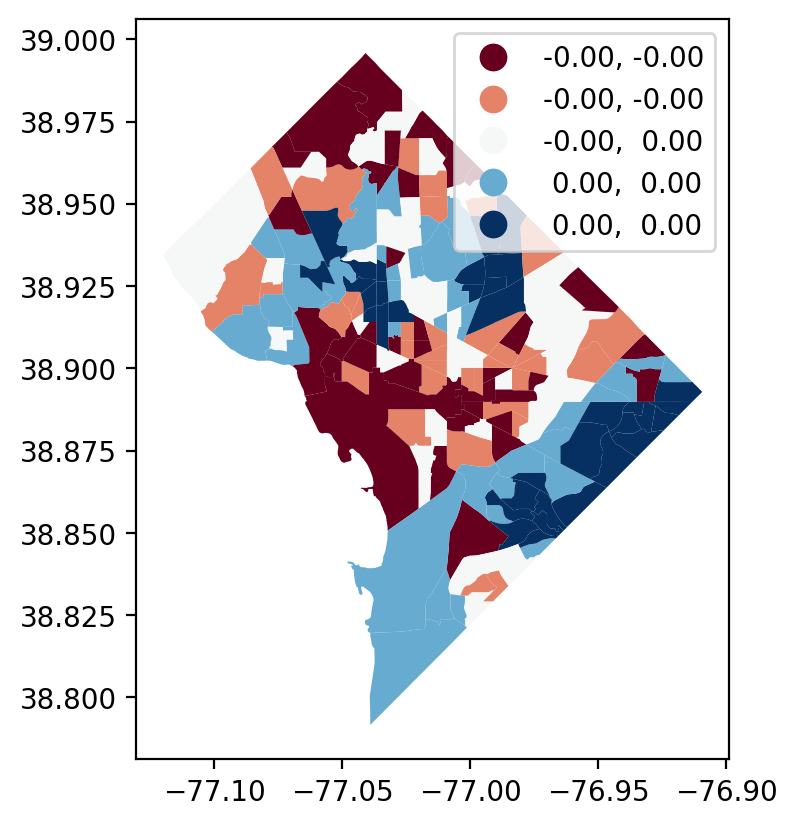

In [15]:
from esda.moran import Moran

# Fit plain MNL for comparison
model_mnl = ChoiceModel(ct, formula=formula)
result_mnl = model_mnl.fit()
probs_mnl = model_mnl.probabilities()

# Get W as dense matrix for utility decomposition
W_dense = np.asarray(W.sparse.todense(), dtype=np.float64)

# Moran's I on probability vectors
moran_sar = Moran(probs_scl[0], W)
moran_mnl = Moran(probs_mnl[0], W)
print(f"Moran's I (SAR probs): {moran_sar.I:.4f}  (p={moran_sar.p_sim:.4f})")
print(f"Moran's I (MNL probs): {moran_mnl.I:.4f}  (p={moran_mnl.p_sim:.4f})")

# Show how spatial filter transforms utilities
rho_est = float(result_scl.coefficients["rho"])
A = np.eye(n_alts) - rho_est * W_dense
A_inv = np.linalg.inv(A)
D = np.diag(A_inv)

beta_est = np.array([result_scl.coefficients["cost"], result_scl.coefficients["time"]])
dm = np.asarray(model_scl._arrays.design_matrix, dtype=np.float64)
V_base = (dm @ beta_est).reshape(n_obs, n_alts)[0]
V_filtered = np.linalg.solve(A, V_base)
V_star = V_filtered / D

# Moran's I on utility vectors (estimated rho)
moran_V_base = Moran(V_base, W)
moran_V_filtered = Moran(V_filtered, W)
moran_V_star = Moran(V_star, W)
print(f"\nMoran's I (V_base):     {moran_V_base.I:.4f}  (p={moran_V_base.p_sim:.4f})")
print(f"Moran's I (V_filtered): {moran_V_filtered.I:.4f}  (p={moran_V_filtered.p_sim:.4f})")
print(f"Moran's I (V_star):     {moran_V_star.I:.4f}  (p={moran_V_star.p_sim:.4f})")

print(f"\nρ = {rho_est:.4f}")
print(f"V_base std:  {V_base.std():.4f}")
print(f"V_filtered std: {V_filtered.std():.4f}")
print(f"V_star std:  {V_star.std():.4f}")
print(f"D range: [{D.min():.4f}, {D.max():.4f}]")

# Map the difference between SAR and MNL probabilities
dc.assign(
    sar_prob=probs_scl[0],
    mnl_prob=probs_mnl[0],
    diff=probs_scl[0] - probs_mnl[0],
).plot("diff", scheme="quantiles", legend=True, cmap="RdBu")

In [16]:
# --- Diagnostic: verify spatial filter creates spatial autocorrelation ---
# The SAR model says V_star = (I - ρW)^{-1} V_base / D
# If ρ > 0, the spatial filter should smooth V_base across neighbors,
# creating spatial autocorrelation in V_star across alternatives.
#
# Key insight: alternatives are spatial locations connected by W.
# The spatial filter creates correlation ACROSS ALTERNATIVES, not across choosers.
# With only alternative-level attributes (cost, time), V_base is the same
# for all choosers — the spatial structure comes entirely from (I - ρW)^{-1}.

rho_true = scl_dataset.true_rho  # 0.5
A_true = np.eye(n_alts) - rho_true * W_dense
A_true_inv = np.linalg.inv(A_true)
D_true = np.diag(A_true_inv)

# V_base is the same for all choosers (only alt-level attributes)
V_base_vec = V_base  # shape (n_alts,)

# Apply spatial filter with TRUE rho
V_filtered_true = np.linalg.solve(A_true, V_base_vec)
V_star_true = V_filtered_true / D_true

# Moran's I on utility vectors (TRUE rho)
moran_V_filtered_true = Moran(V_filtered_true, W)
moran_V_star_true = Moran(V_star_true, W)

print("=== Spatial autocorrelation in utility vectors ===")
print(f"True ρ = {rho_true:.1f}, Estimated ρ = {rho_est:.4f}")
print(f"\nMoran's I (V_base):          {moran_V_base.I:.4f}  (p={moran_V_base.p_sim:.4f})")
print(f"Moran's I (V_filtered, ρ̂):  {moran_V_filtered.I:.4f}  (p={moran_V_filtered.p_sim:.4f})")
print(f"Moran's I (V_star, ρ̂):      {moran_V_star.I:.4f}  (p={moran_V_star.p_sim:.4f})")
print(
    f"Moran's I (V_filtered, ρ=0.5): {moran_V_filtered_true.I:.4f}  (p={moran_V_filtered_true.p_sim:.4f})"
)
print(f"Moran's I (V_star, ρ=0.5):   {moran_V_star_true.I:.4f}  (p={moran_V_star_true.p_sim:.4f})")

print(f"\nV_base std:     {V_base_vec.std():.4f}")
print(f"V_filtered std (ρ̂): {V_filtered.std():.4f}")
print(f"V_star std (ρ̂):     {V_star.std():.4f}")
print(f"V_filtered std (ρ=0.5): {V_filtered_true.std():.4f}")
print(f"V_star std (ρ=0.5):     {V_star_true.std():.4f}")
print(f"D range (ρ̂): [{D.min():.4f}, {D.max():.4f}]")
print(f"D range (ρ=0.5): [{D_true.min():.4f}, {D_true.max():.4f}]")

# Probabilities with true rho
probs_true = np.exp(V_star_true) / np.exp(V_star_true).sum()
moran_probs_true = Moran(probs_true, W)
moran_probs_mnl_vec = Moran(np.exp(V_base_vec) / np.exp(V_base_vec).sum(), W)
print(f"\nMoran's I (probs SAR, ρ̂):  {moran_sar.I:.4f}  (p={moran_sar.p_sim:.4f})")
print(f"Moran's I (probs SAR, ρ=0.5): {moran_probs_true.I:.4f}  (p={moran_probs_true.p_sim:.4f})")
print(
    f"Moran's I (probs MNL):       {moran_probs_mnl_vec.I:.4f}  (p={moran_probs_mnl_vec.p_sim:.4f})"
)

=== Spatial autocorrelation in utility vectors ===
True ρ = 0.5, Estimated ρ = 0.4761

Moran's I (V_base):          -0.0418  (p=0.1920)
Moran's I (V_filtered, ρ̂):  0.1561  (p=0.0010)
Moran's I (V_star, ρ̂):      0.1559  (p=0.0010)
Moran's I (V_filtered, ρ=0.5): 0.1711  (p=0.0010)
Moran's I (V_star, ρ=0.5):   0.1707  (p=0.0010)

V_base std:     0.4835
V_filtered std (ρ̂): 0.5079
V_star std (ρ̂):     0.4835
V_filtered std (ρ=0.5): 0.5121
V_star std (ρ=0.5):     0.4844
D range (ρ̂): [1.0320, 1.0795]
D range (ρ=0.5): [1.0358, 1.0900]

Moran's I (probs SAR, ρ̂):  0.1267  (p=0.0060)
Moran's I (probs SAR, ρ=0.5): 0.1409  (p=0.0030)
Moran's I (probs MNL):       -0.0565  (p=0.1130)


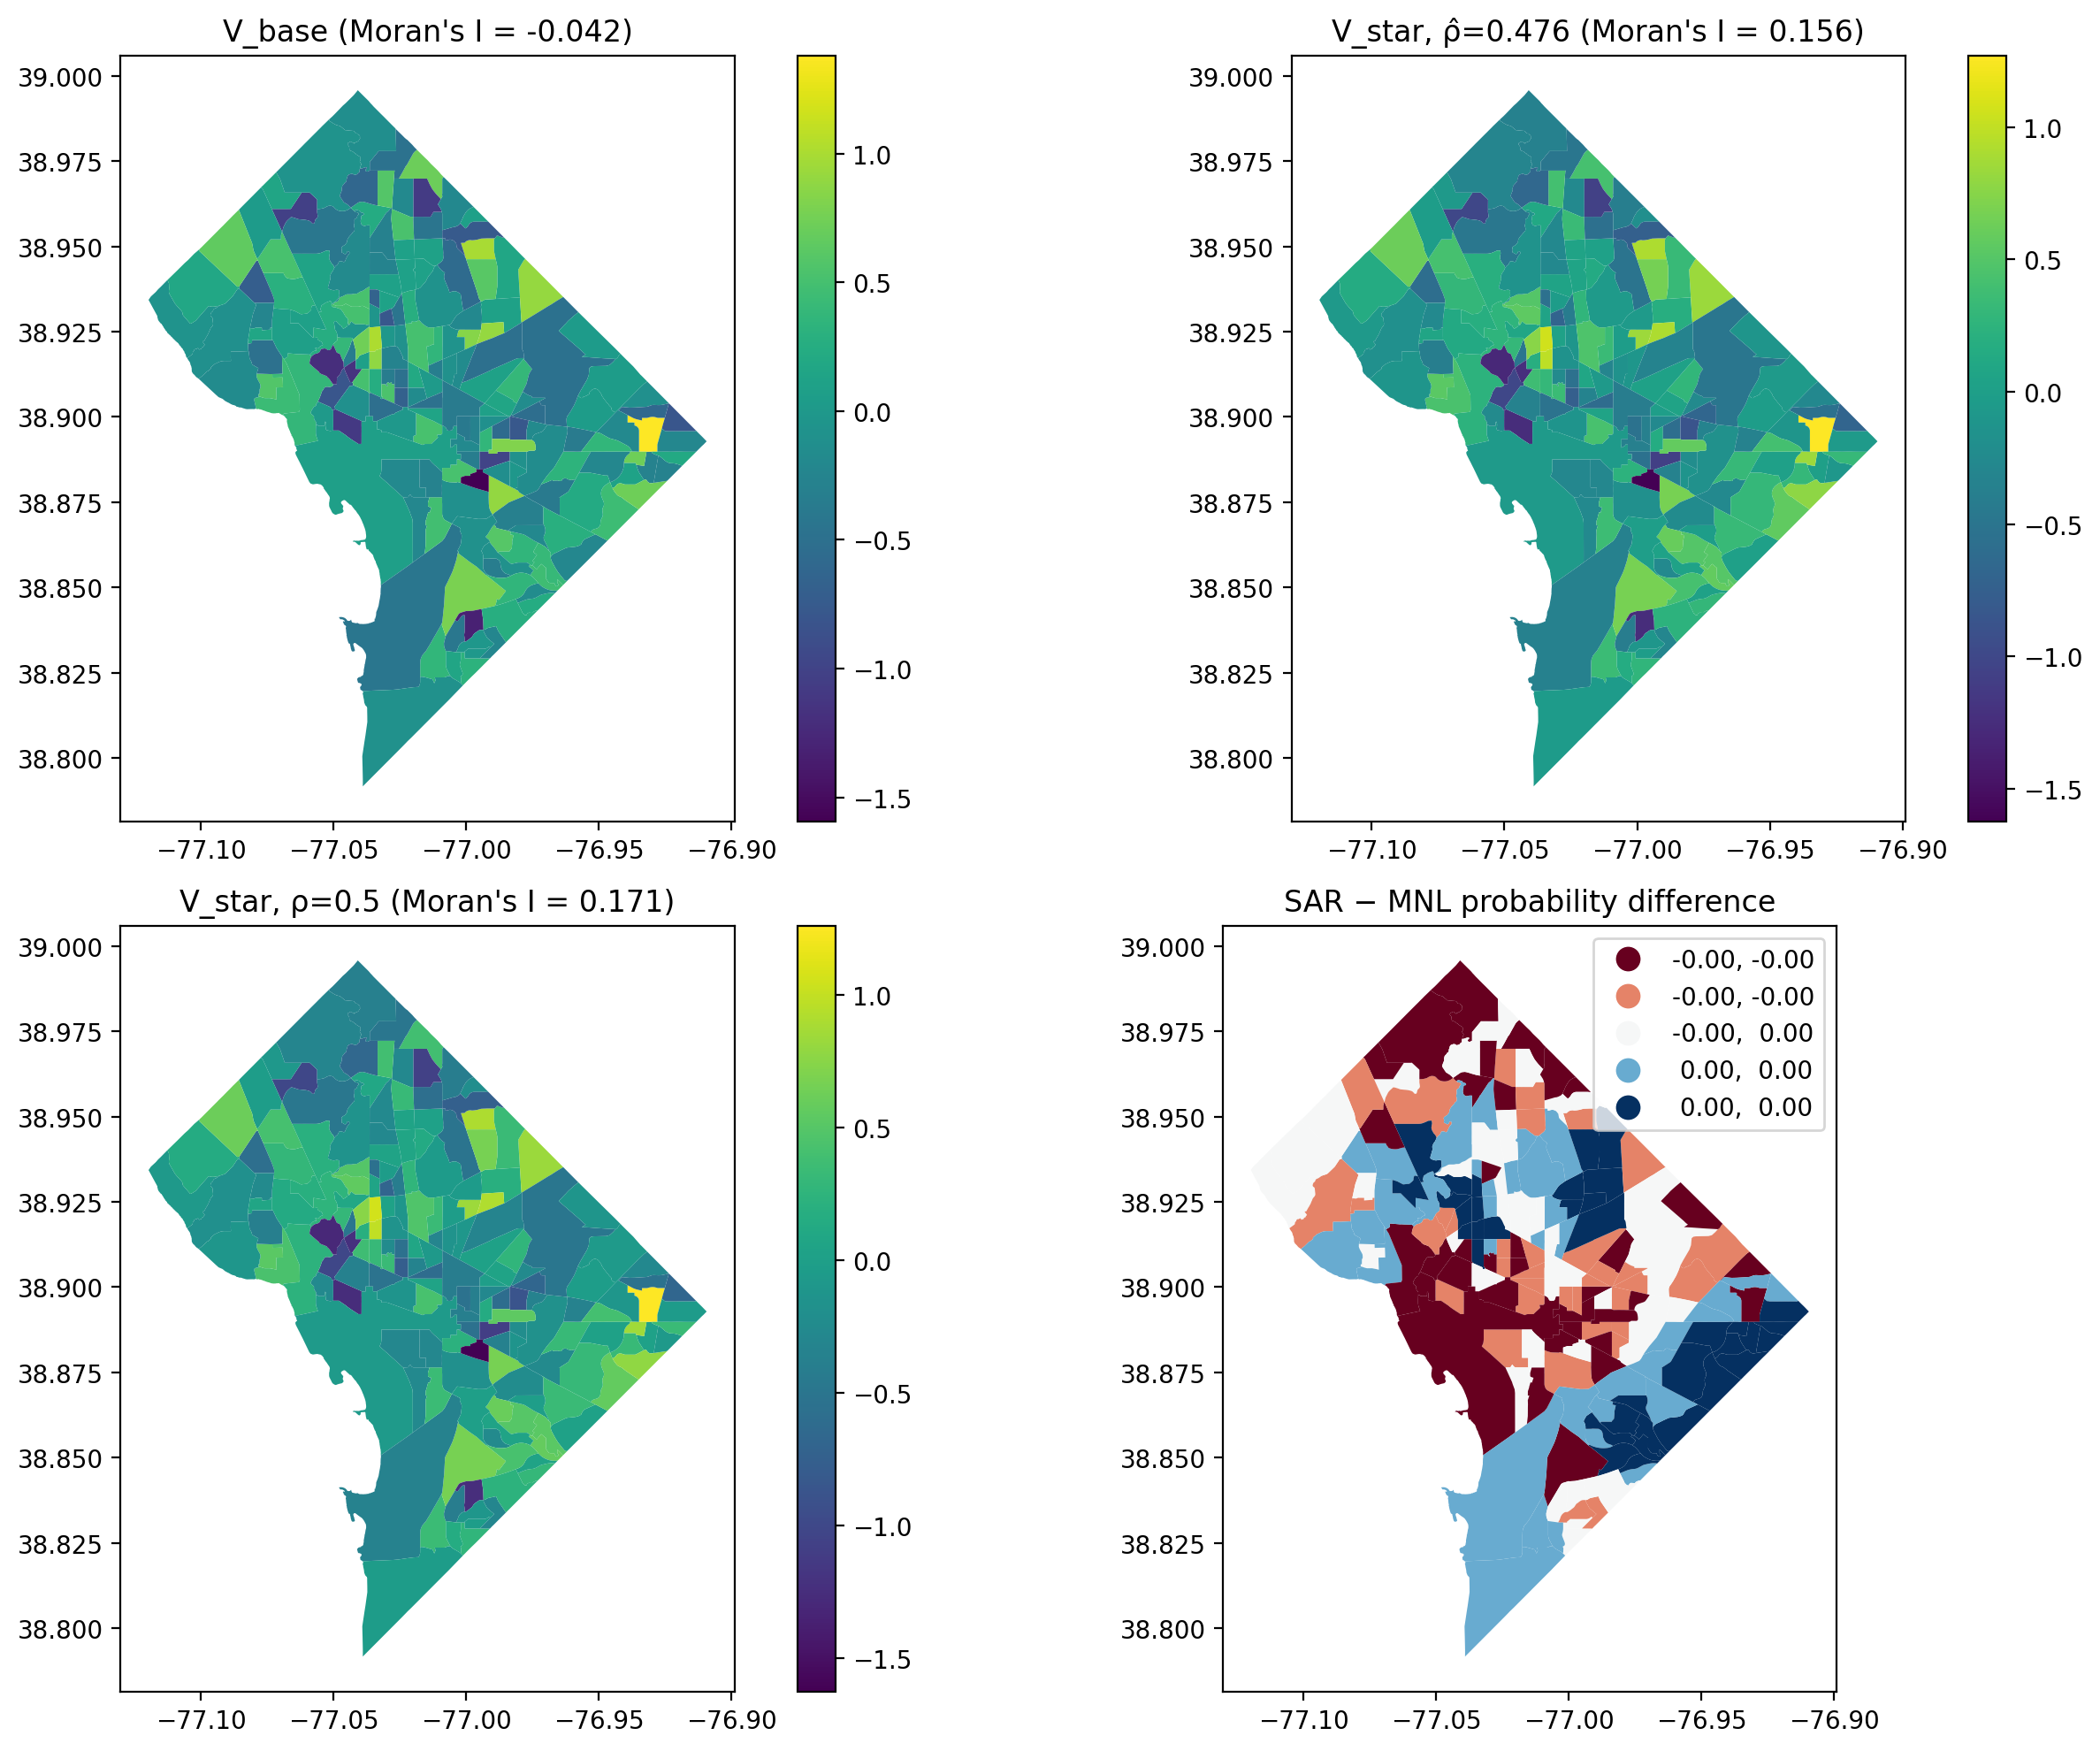

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. V_base (no spatial structure — random attributes)
dc.assign(V_base=V_base).plot("V_base", ax=axes[0, 0], legend=True, cmap="viridis")
axes[0, 0].set_title(f"V_base (Moran's I = {moran_V_base.I:.3f})")

# 2. V_star with estimated rho (spatially filtered)
dc.assign(V_star=V_star).plot("V_star", ax=axes[0, 1], legend=True, cmap="viridis")
axes[0, 1].set_title(f"V_star, ρ̂={rho_est:.3f} (Moran's I = {moran_V_star.I:.3f})")

# 3. V_star with true rho (stronger spatial pattern)
dc.assign(V_star_true=V_star_true).plot("V_star_true", ax=axes[1, 0], legend=True, cmap="viridis")
axes[1, 0].set_title(f"V_star, ρ=0.5 (Moran's I = {moran_V_star_true.I:.3f})")

# 4. SAR vs MNL probability difference
dc.assign(
    sar_prob=probs_scl[0],
    mnl_prob=probs_mnl[0],
    diff=probs_scl[0] - probs_mnl[0],
).plot("diff", ax=axes[1, 1], scheme="quantiles", legend=True, cmap="RdBu")
axes[1, 1].set_title("SAR − MNL probability difference")

plt.tight_layout()
plt.show()